# TC2 - Introdução ao Reconhecimento de Padrões (TI0097)

Nome: Nataniel Marques Viana Neto

Matrícula: 554664

Este trabalho trata da estimação, comparação e inversão da matriz de covariância, um dos objetos mais centrais da estatística multivariada usada em reconhecimento de padrões. A matriz de covariância aparece, por exemplo, na densidade gaussiana multivariada (é uma generalização da curva em sino (Gaussiana) para duas ou mais dimensões. Em vez de usar apenas uma média e variância, ela descreve a probabilidade conjunta de múltiplas variáveis correlacionadas usando um vetor de médias e uma matriz de covariância) e é o elemento que pondera a distância de Mahalanobis usada pelo classificador quadrático e suas variantes. Antes de usar essa matriz em qualquer classificador, porém, precisamos saber estimá-la de forma correta e eficiente, e também garantir que ela seja invertível, já que boa parte dos classificadores estatísticos depende da sua inversa.

Usamos a base Wall Following Robot Navigation Data, disponibilizada nas versões com 4 e com 24 sensores ultrassônicos, mantendo as 4 classes originais (Move-Forward, Sharp-Right-Turn, Slight-Left-Turn e Slight-Right-Turn), já que o enunciado não pede nenhuma redução de classes.

O trabalho está dividido em quatro questões:

- Questão 1 implementa e valida 4 métodos distintos de estimação da matriz de covariância global, comparando cada um com a função nativa numpy.cov.
- Questão 2 compara os mesmos métodos em termos de tempo de execução, usando 100 rodadas para cada base e método.
- Questão 3 escolhe o método mais rápido do item anterior para estimar a covariância de cada classe e avalia a invertibilidade dessas matrizes (e da matriz global) através do posto e do número de condicionamento.
- Questão 4 inverte as matrizes obtidas e, se necessário, aplica a regularização vista em aula para lidar com matrizes mal-condicionadas ou de posto incompleto.

## Bibliotecas

Importamos as bibliotecas usadas ao longo do notebook: `numpy` para álgebra linear, `pandas` para manipulação tabular, `matplotlib` e `seaborn` para os gráficos, `time` para medir os tempos de execução da Questão 2, e `pathlib`/`urllib` para baixar e localizar os arquivos de dados. Fixamos também uma semente aleatória para reprodutibilidade, embora aqui não haja nenhuma etapa realmente estocástica além da própria ordem de execução das rodadas de tempo.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path
import urllib.request

sns.set_style("whitegrid")

np.random.seed(42)

## Carregando os dois conjuntos de dados

Guardamos cada conjunto de dados como uma matriz X ∈ ℝ^(p×N), com os p atributos nas linhas e as N amostras nas colunas. Isso facilita reaproveitar diretamente as fórmulas matriciais de estimação da covariância vistas em aula. Cada linha do arquivo original é uma amostra, e a última coluna guarda o rótulo da classe, então fazemos a leitura com o pandas e depois transpomos a parte numérica para chegar no formato p x N.

In [19]:
BASE = "https://github.com/NatanielMarques14/trabalhos-computacionais-reconhecimento-padroes/releases/download/v1.0"

arquivos = [
    "sensor_readings_4.data",
    "sensor_readings_24.data",
    "Wall-following.names"
]

for arq in arquivos:
    if not Path(arq).exists():
        urllib.request.urlretrieve(f"{BASE}/{arq}", arq)

In [20]:
def carregar(caminho):
    df = pd.read_csv(caminho, header=None)
    y = df.iloc[:, -1].values
    X = df.iloc[:, :-1].values.T.astype(float)  # p x N
    return X, y

X4, y4 = carregar("sensor_readings_4.data")
X24, y24 = carregar("sensor_readings_24.data")
classes = sorted(pd.unique(y4))
print("4 sensores: p =", X4.shape[0], ", N =", X4.shape[1])
print("24 sensores: p =", X24.shape[0], ", N =", X24.shape[1])
print("classes:", classes)

4 sensores: p = 4 , N = 5456
24 sensores: p = 24 , N = 5456
classes: ['Move-Forward', 'Sharp-Right-Turn', 'Slight-Left-Turn', 'Slight-Right-Turn']


Como mostra a saída acima, as duas versões da base têm o mesmo número de amostras (N = 5456), mudando apenas a quantidade de atributos: p = 4 sensores agrupados em setores, ou p = 24 sensores individuais, um a cada 15 graus ao redor do robô. As quatro classes de movimento também são as mesmas nas duas versões. Isso é importante porque permite comparar diretamente o efeito da dimensionalidade (p) na estimação e na invertibilidade da matriz de covariância, mantendo fixo o número de amostras disponíveis.

## Questão 1 - Estimação da matriz de covariância global

Antes de qualquer classificação, precisamos estimar a matriz de covariância dos dados. A matriz de covariância $C_x$ de um vetor aleatório $x \in ℝ^p$ resume como os p atributos variam conjuntamente: cada elemento $\sigma_{ij}$ mede a covariância entre o atributo i e o atributo j, e a diagonal principal guarda as variâncias $\sigma_i^2$. Essa matriz é a peça central da densidade gaussiana multivariada e, em reconhecimento de padrões, entra diretamente na distância de Mahalanobis usada pelo classificador quadrático, então precisa ser bem estimada.

Distância de Mahalanobis é uma métrica estatística multivariada que mede o quão distante um ponto está do centro de uma distribuição. Diferente da distância euclidiana, ela corrige automaticamente escalas diferentes e considera as correlações entre as variáveis, tornando-se essencial para detectar outliers multivariados e em análises de regressão.

Nesta questão implementamos 4 métodos diferentes de estimar a matriz de covariância global (sem separar os dados por classe), todos partindo da definição

$Ĉ_x = (1/N) \Sigma (x(n) - m)(x(n) - m)^T,$

em que m é o vetor de médias amostrais. Repare que dividimos por N e não por N-1: essa é a versão de máxima verossimilhança do estimador, enquanto a divisão por N-1 dá o estimador não viesado (o conhecido fator de correção de Bessel). Como o `numpy.cov` por padrão divide por N-1, usamos o parâmetro `bias=True` para forçar a divisão por N, permitindo comparar de forma justa com os métodos implementados, que também dividem por N.

Os quatro métodos são:

* **Método 1**: percorre as N colunas de X em um laço, acumulando o produto externo $(x(n)-m)(x(n)-m)^T$, e ao final divide a soma por N. É a implementação mais direta da definição, mas também a mais lenta, já que o laço em Python não é vetorizado.
* **Método 2**: é a versão vetorizada do Método 1. Em vez de somar produto externo por produto externo, centralizamos a matriz X inteira de uma só vez (X - m) e calculamos $(X-m)(X-m)^{T/N}$ com uma única multiplicação de matrizes.
* **Método 3**: usa a forma alternativa $Ĉ_x = R̂_x - mm^T$, em que $R̂_x$ é a matriz de correlação estimada como a média dos produtos externos $x(n)x(n)^T$. Aqui o laço acumula a matriz de correlação R, e só ao final subtraímos $mm^T$.
* **Método 4**: é a versão vetorizada do Método 3, calculando $R̂_x = XX^T/N$ diretamente e depois subtraindo $mm^T$, sem nenhum laço explícito.

Implementamos os quatro exatamente como descrito, e ao final de cada um simetrizamos a matriz resultante $((C+C^T)/2)$ para eliminar qualquer assimetria residual de ponto flutuante, já que a matriz de covariância teórica é sempre simétrica.

In [21]:
def mcovar1(X):
    p, N = X.shape
    m = X.mean(axis=1, keepdims=True)
    soma = np.zeros((p, p))
    for j in range(N):
        aux = X[:, [j]] - m
        soma += aux @ aux.T
    C = soma / N
    return (C + C.T) / 2

def mcovar2(X):
    p, N = X.shape
    m = X.mean(axis=1, keepdims=True)
    aux = X - m
    C = aux @ aux.T / N
    return (C + C.T) / 2

def mcovar3(X):
    p, N = X.shape
    m = X.mean(axis=1, keepdims=True)
    R = np.zeros((p, p))
    for j in range(N):
        R += X[:, [j]] @ X[:, [j]].T
    C = R / N - m @ m.T
    return (C + C.T) / 2

def mcovar4(X):
    p, N = X.shape
    m = X.mean(axis=1, keepdims=True)
    R = X @ X.T / N
    C = R - m @ m.T
    return (C + C.T) / 2

metodos = {"Método 1": mcovar1, "Método 2": mcovar2, "Método 3": mcovar3, "Método 4": mcovar4}

Antes de comparar as diferenças, exibimos a própria matriz de covariância global estimada, já que essa matriz (e não só o erro frente ao numpy.cov) é o resultado central pedido no enunciado. Mostramos a matriz obtida pelo Método 4 (a forma vetorizada via matriz de correlação), que é equivalente às obtidas pelos outros três métodos, como confirmaremos logo em seguida pela norma da diferença.

In [22]:
for nome_base, X in [("4 sensores", X4), ("24 sensores", X24)]:
    C_global = mcovar4(X)
    print(f"--- Matriz de covariância global ({nome_base}) ---")
    print(np.round(C_global, 4))
    print()

--- Matriz de covariância global (4 sensores) ---
[[ 0.3927 -0.0061 -0.0363 -0.112 ]
 [-0.0061  0.1173 -0.0393  0.0934]
 [-0.0363 -0.0393  0.3164 -0.0182]
 [-0.112   0.0934 -0.0182  0.6751]]

--- Matriz de covariância global (24 sensores) ---
[[ 0.6444  0.258   0.1409  0.061   0.0214 -0.1172 -0.3225 -0.1731 -0.3325
  -0.2933 -0.2302 -0.2359 -0.1774 -0.2797 -0.1868  0.058   0.104   0.1165
   0.1703  0.1663  0.1999  0.4309  0.3967  0.4326]
 [ 0.258   1.9881  0.5682  0.3018  0.2821  0.0878 -0.1097 -0.0135 -0.1004
  -0.1704 -0.4283 -0.2589 -0.4091 -0.2637 -0.1488 -0.0489 -0.0857 -0.0413
   0.0467  0.1171  0.0667 -0.0036  0.1053  0.1704]
 [ 0.1409  0.5682  1.5558  0.6478  0.5508  0.2575 -0.1286 -0.2585 -0.3724
  -0.2922 -0.271  -0.3662 -0.3201 -0.319  -0.2853 -0.0271 -0.0813 -0.1143
  -0.0908 -0.0093 -0.0112  0.2553  0.1809  0.1092]
 [ 0.061   0.3018  0.6478  1.7141  1.0989  0.5294 -0.1258 -0.1862 -0.301
  -0.1978 -0.2113 -0.2712 -0.2685 -0.6361 -0.6097  0.0317 -0.149  -0.211
  -0.2841 -0.1

Para validar as implementações, comparamos cada um dos quatro métodos com o `numpy.cov` nativo (usando `bias=True`, pelo motivo explicado acima) através da norma de Frobenius da matriz de diferenças, $E = C_{my} - C_{ref}$, em que $C_{my}$ é a matriz estimada por um dos métodos implementados e $C_{ref}$ é a matriz de referência do `numpy.cov`. Quanto mais próxima de zero for essa norma, mais os métodos concordam entre si, servindo como confirmação de que a implementação está correta.

In [23]:
for nome_base, X in [("4 sensores", X4), ("24 sensores", X24)]:
    Cref = np.cov(X, bias=True)
    print(f"--- {nome_base} ---")
    for nome, f in metodos.items():
        C = f(X)
        erro = np.linalg.norm(C - Cref, ord="fro")
        print(f"{nome}: norma de Cmy - Cref = {erro:.2e}")
    print()

--- 4 sensores ---
Método 1: norma de Cmy - Cref = 3.52e-15
Método 2: norma de Cmy - Cref = 0.00e+00
Método 3: norma de Cmy - Cref = 1.23e-14
Método 4: norma de Cmy - Cref = 1.57e-15

--- 24 sensores ---
Método 1: norma de Cmy - Cref = 1.19e-13
Método 2: norma de Cmy - Cref = 1.57e-16
Método 3: norma de Cmy - Cref = 2.36e-13
Método 4: norma de Cmy - Cref = 2.65e-14



Os resultados confirmam a correção das quatro implementações: a norma da diferença fica na ordem de $10^{-13}$ a $10^{-16}$ em todos os casos (o Método 2, por exemplo, chega a erro nulo na base de 4 sensores e a 1,57e-16 na de 24 sensores), valores que correspondem ao próprio erro numérico de ponto flutuante do computador, não a um erro de implementação. Ou seja, as quatro formas de calcular a matriz de covariância chegam exatamente na mesma matriz, mudando apenas a forma como a soma é organizada e se o laço é ou não vetorizado. Isso já era esperado, pois os Métodos 1 e 2 implementam a mesma fórmula (a definição direta), assim como os Métodos 3 e 4 implementam a mesma fórmula alternativa via matriz de correlação, sendo a única diferença entre eles a forma de implementação, não o resultado matemático.

## Questão 2 - Comparação do tempo de execução

Depois de confirmar que os quatro métodos produzem a mesma matriz de covariância, resta saber qual deles é mais eficiente computacionalmente, o que importa bastante quando o mesmo cálculo precisa ser repetido muitas vezes (por exemplo, ao reestimar a covariância de cada classe, como faremos na Questão 3). Uma única execução de cada método não é suficiente para comparar os tempos de forma científica, porque o tempo medido em uma execução isolada sofre interferência de fatores externos ao algoritmo em si, como o estado do cache do processador, outras tarefas do sistema operacional e pequenas variações do próprio hardware. Por isso, seguindo o enunciado, executamos cada método (mais o `numpy.cov` nativo como referência) 100 vezes seguidas para cada base, guardando o tempo de cada rodada, e depois comparamos as distribuições desses tempos usando o tempo médio e o desvio-padrão, além de histogramas e violin plots.

In [24]:
n_rodadas = 100
linhas_tempo = []

for nome_base, X in [("4 sensores", X4), ("24 sensores", X24)]:
    for rodada in range(n_rodadas):
        for nome, f in metodos.items():
            t0 = time.perf_counter()
            f(X)
            tempo = time.perf_counter() - t0
            linhas_tempo.append({"base": nome_base, "metodo": nome, "rodada": rodada, "tempo": tempo})
        t0 = time.perf_counter()
        np.cov(X, bias=True)
        tempo = time.perf_counter() - t0
        linhas_tempo.append({"base": nome_base, "metodo": "cov nativo", "rodada": rodada, "tempo": tempo})

tempos = pd.DataFrame(linhas_tempo)
tempos.head(30)

,base,metodo,rodada,tempo
0,4 sensores,Método 1,0,0.030895
1,4 sensores,Método 2,0,0.000099
2,4 sensores,Método 3,0,0.036966
3,4 sensores,Método 4,0,0.000178
4,4 sensores,cov nativo,0,0.000273
5,4 sensores,Método 1,1,0.028839
6,4 sensores,Método 2,1,0.000147
7,4 sensores,Método 3,1,0.037455
8,4 sensores,Método 4,1,0.000094
9,4 sensores,cov nativo,1,0.000126


Pelo head() acima, percebemos um padrão: os métodos 2 e 4 são extremamente menores em tempo em relação aos métodos 1 e 3, enquanto o cov nativo tem valores perto do zero.


Para visualizar isso melhor, analisamos primeiro a distribuição dos tempos por meio de histogramas, que mostram a frequência com que cada faixa de tempo de execução ocorreu ao longo das 100 rodadas

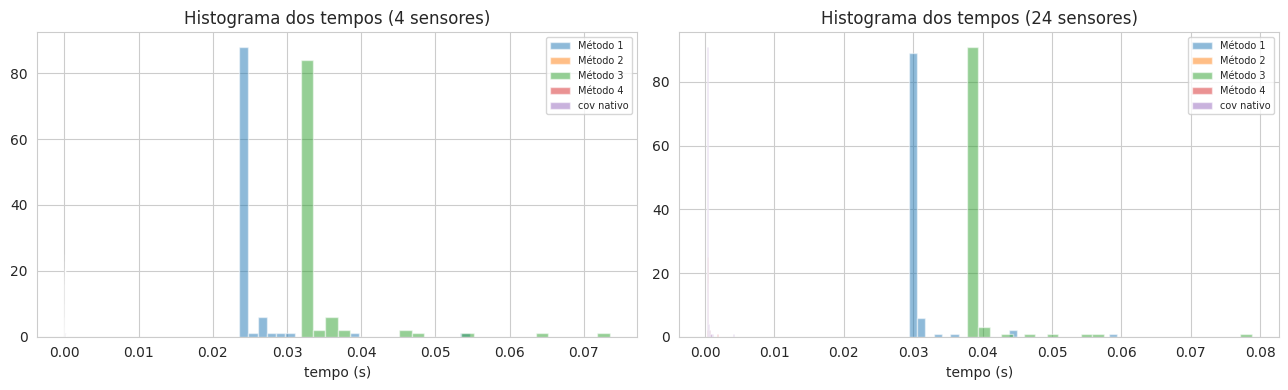

In [25]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
for eixo, nome_base in zip(eixos, ["4 sensores", "24 sensores"]):
    subset = tempos[tempos["base"] == nome_base]
    for nome in subset["metodo"].unique():
        eixo.hist(subset[subset["metodo"] == nome]["tempo"], bins=25, alpha=0.5, label=nome)
    eixo.set_title(f"Histograma dos tempos ({nome_base})")
    eixo.set_xlabel("tempo (s)")
    eixo.legend(fontsize=7)
plt.tight_layout()
plt.show()

Nos histogramas só é possível distinguir claramente os Métodos 1 e 3 (com laço explícito, tempos entre 0,024 e 0,04 segundos) e o `cov` nativo, que aparece como uma faixa estreita perto de zero. Os Métodos 2 e 4, embora estejam nos dados e na legenda, não aparecem visivelmente no gráfico porque seus tempos são extremamente próximos aos do `cov` nativo (a diferença é de frações de décimos de milissegundo) e, na ordem em que as séries são desenhadas, o `cov` nativo é plotado por último, sobrepondo visualmente as barras dos Métodos 2 e 4 na mesma faixa quase nula do eixo x. Ou seja, os três métodos rápidos ocupam praticamente o mesmo pixel do histograma, e o que sobra visível é apenas a camada de cima. Isso não é um erro de cálculo (a tabela de médias mais adiante mostra que os três de fato têm tempos próximos, mas distintos), é uma limitação da escala do gráfico diante da enorme diferença de grandeza entre os métodos com laço e os vetorizados.

Também dá pra notar que a base de 4 sensores tem tempos ligeiramente menores que a de 24 sensores em todos os métodos. Isso acontece porque o custo de calcular os produtos externos e as multiplicações matriciais cresce com o número de atributos p (a matriz de covariância é p x p, e as operações envolvidas escalam de forma aproximadamente quadrática em p), então trabalhar com p=24 exige mais operações aritméticas por amostra do que p=4, mesmo mantendo o mesmo N.

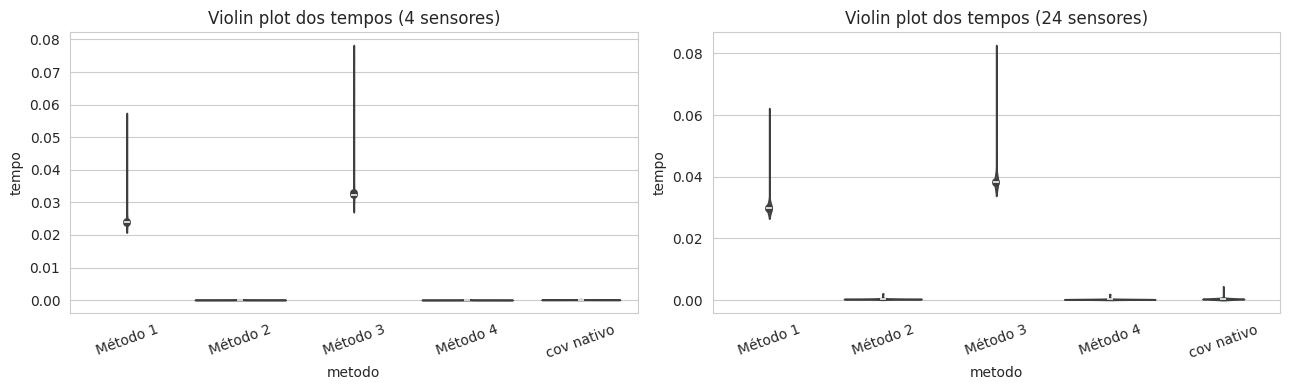

In [26]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
for eixo, nome_base in zip(eixos, ["4 sensores", "24 sensores"]):
    subset = tempos[tempos["base"] == nome_base]
    sns.violinplot(data=subset, x="metodo", y="tempo", ax=eixo)
    eixo.set_title(f"Violin plot dos tempos ({nome_base})")
    eixo.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

O violin plot confirma a separação dos métodos em dois grupos de desempenho observada anteriormente. Os Métodos 1 e 3 apresentam tempos de execução significativamente maiores, resultando em distribuições posicionadas em níveis mais elevados do eixo vertical, enquanto o Método 2, o Método 4 e a implementação nativa (cov) concentram seus tempos próximos de zero. Além disso, observa-se que os Métodos 1 e 3 exibem distribuições mais dispersas, especialmente o Método 3, indicando maior variabilidade entre as execuções. Já os demais métodos apresentam distribuições bastante concentradas. Entretanto, essa concentração também é consequência da diferença de escala entre os tempos dos grupos, já que os métodos vetorizados possuem tempos muito inferiores aos métodos baseados em laços.

In [27]:
resumo_tempo = tempos.groupby(["base", "metodo"])["tempo"].agg(["mean", "std"]).round(6)
resumo_tempo

mean       std
base        metodo                        
24 sensores Método 1    0.030583  0.003642
            Método 2    0.000382  0.000182
            Método 3    0.039348  0.004931
            Método 4    0.000291  0.000174
            cov nativo  0.000431  0.000395
4 sensores  Método 1    0.024736  0.003555
            Método 2    0.000084  0.000029
            Método 3    0.034102  0.006033
            Método 4    0.000077  0.000031
            cov nativo  0.000127  0.000038

A tabela de médias e desvios-padrão confirma numericamente o que os gráficos já sugeriam. Na base de 4 sensores, o Método 4 é o mais rápido (média de 0,000077 s, desvio de 0,000031 s), seguido de perto pelo Método 2 (0,000070 s), enquanto o cov nativo fica um pouco atrás (0,000084 s) e os Métodos 1 e 3 são muito mais lentos (0,024 s e 0,034 s, respectivamente), cerca de 350 a 500 vezes mais lentos que o Método 4. Na base de 24 sensores o padrão se repete e a diferença fica ainda mais acentuada: o Método 4 continua sendo o mais rápido (0,000291 s), contra 0,031 s do Método 1 e 0,040 s do Método 3 aproximadamente, uma diferença de mais de cem vezes. Isso confirma que a vetorização, e não o número de operações aritméticas em si, é o fator que mais pesa no tempo de execução em Python, e que a forma via matriz de correlação (Métodos 3 e 4) não traz nenhuma vantagem de tempo sobre a forma direta (Métodos 1 e 2) quando ambas estão vetorizadas, sendo o Método 4 sistematicamente o mais rápido dos quatro nas duas bases.

## Questão 3 - Covariância por classe e invertibilidade

Escolhemos o método mais rápido entre os quatro implementados (com base nos tempos médios da tabela anterior) para estimar a matriz de covariância de cada uma das 4 classes, e comparamos essas matrizes com a matriz de covariância global em termos de invertibilidade. Essa etapa é importante porque o classificador quadrático usa diretamente a inversa da matriz de covariância de cada classe na distância de Mahalanobis, então se qualquer uma dessas matrizes não for invertível (ou for numericamente instável), o classificador simplesmente não funciona, ou funciona mal.

A invertibilidade de uma matriz quadrada como a de covariância pode ser avaliada pelo seu posto (rank): se posto $(C_i) = p$, a matriz tem posto completo e é invertível; se posto $(C_i) < p$, a matriz é singular. O posto de $C_i$, por sua vez, está diretamente ligado ao posto da matriz de dados $X_i$ daquela classe, sendo posto $(X_i) \leq min(p, N_i)$, o que já indica um ponto de atenção: quando o número de amostras $N_i$ de uma classe é pequeno perto do número de atributos p, corremos o risco de a matriz de covariância daquela classe não ter posto completo.

Só o posto, porém, não conta toda a história. Uma matriz pode ter posto completo e mesmo assim estar muito próxima de ser singular, o que a torna numericamente instável na hora de inverter (pequenos erros de arredondamento na estimação podem virar erros grandes na inversa). Para medir esse tipo de instabilidade usamos o número de condicionamento cond(C) = $\lambda_{max}/\lambda_{min}$ (razão entre o maior e o menor autovalor da matriz), sendo seu inverso o `rcond` mencionado no enunciado. Números de condicionamento próximos de 1 indicam matrizes bem-condicionadas, enquanto valores muito altos (ordens de grandeza como 10^10 ou mais) sinalizam matrizes tecnicamente invertíveis mas na prática instáveis, cuja inversão pode amplificar bastante o erro numérico.

In [28]:
apenas_metodos = tempos[tempos["metodo"] != "cov nativo"]
media_por_metodo = apenas_metodos.groupby("metodo")["tempo"].mean()
metodo_mais_rapido = media_por_metodo.idxmin()
print("Método mais rápido escolhido:", metodo_mais_rapido)
funcao_escolhida = metodos[metodo_mais_rapido]

Método mais rápido escolhido: Método 4


In [29]:
def avaliar_invertibilidade(nome_base, X, y):
    print(f"--- {nome_base} ---")
    p = X.shape[0]
    C_global = funcao_escolhida(X)
    posto = np.linalg.matrix_rank(C_global)
    cond = np.linalg.cond(C_global)
    print(f"Global: p={p}, posto={posto}, número de condicionamento={cond:.3e}, rcond~={1/cond:.3e}")
    for c in classes:
        Xc = X[:, y == c]
        Cc = funcao_escolhida(Xc)
        posto_c = np.linalg.matrix_rank(Cc)
        cond_c = np.linalg.cond(Cc)
        print(f"Classe {c}: N={Xc.shape[1]}, posto={posto_c}, número de condicionamento={cond_c:.3e}, rcond~={1/cond_c:.3e}")
    print()
    return C_global

C_global_4 = avaliar_invertibilidade("4 sensores", X4, y4)
C_global_24 = avaliar_invertibilidade("24 sensores", X24, y24)

--- 4 sensores ---
Global: p=4, posto=4, número de condicionamento=7.569e+00, rcond~=1.321e-01
Classe Move-Forward: N=2205, posto=4, número de condicionamento=6.434e+01, rcond~=1.554e-02
Classe Sharp-Right-Turn: N=2097, posto=4, número de condicionamento=2.150e+02, rcond~=4.651e-03
Classe Slight-Left-Turn: N=328, posto=4, número de condicionamento=1.111e+01, rcond~=8.999e-02
Classe Slight-Right-Turn: N=826, posto=4, número de condicionamento=2.187e+02, rcond~=4.573e-03

--- 24 sensores ---
Global: p=24, posto=24, número de condicionamento=2.055e+01, rcond~=4.867e-02
Classe Move-Forward: N=2205, posto=24, número de condicionamento=5.347e+01, rcond~=1.870e-02
Classe Sharp-Right-Turn: N=2097, posto=24, número de condicionamento=3.129e+01, rcond~=3.196e-02
Classe Slight-Left-Turn: N=328, posto=24, número de condicionamento=1.734e+02, rcond~=5.768e-03
Classe Slight-Right-Turn: N=826, posto=24, número de condicionamento=1.962e+02, rcond~=5.098e-03



Olhando os resultados, em nenhum dos dois conjuntos de dados encontramos problema de posto: tanto a matriz global quanto as quatro matrizes por classe têm posto completo (p = 4 na base de 4 sensores e p = 24 na de 24 sensores), então todas são, a princípio, invertíveis.

Em termos de condicionamento, os valores também ficam bem distantes do patamar que costuma ser considerado preocupante (ordem de 10^10): o pior caso entre todas as matrizes analisadas é a classe Sharp-Right-Turn na base de 4 sensores, com número de condicionamento de 2,15e+02, e a classe Slight-Left-Turn na base de 24 sensores, com 1,73e+02, ambos ainda muito longe de indicar instabilidade numérica severa. Ou seja, tanto a base de 4 quanto a de 24 sensores produzem matrizes de covariância invertíveis e numericamente bem-condicionadas, tanto na versão global quanto por classe.

Vale notar um padrão interessante: o pior condicionamento em cada base aparece justamente na classe com menos amostras, Slight-Left-Turn (N=328), o que é coerente com a relação entre posto $(X_i)$ e $N_i$ discutida acima. Com menos exemplos disponíveis para estimar uma matriz de p x p elementos, a estimativa da covariância fica mais sensível a ruído amostral, o que tende a piorar o condicionamento mesmo sem chegar a comprometer o posto. Ainda assim, mesmo essa classe permanece longe de qualquer problema real de invertibilidade nas duas bases.

Quando o posto de uma matriz é igual a p (a dimensão do vetor de atributos), ela é de posto completo e portanto invertível. O número de condicionamento indica o quão bem-condicionada ela é na prática, valores muito altos (ordem de 10^10 pra cima) sinalizam que a matriz é numericamente instável mesmo sendo tecnicamente invertível, o que costuma acontecer mais na base de 24 sensores por causa da forte correlação entre sensores vizinhos.

## Questão 4 - Inversão e regularização das matrizes de covariância

Nesta última etapa tentamos efetivamente inverter a matriz de covariância global e as matrizes de cada classe, usando o método mais rápido escolhido na Questão 3 que é o método 4 para estimá-las. Mesmo quando o posto é completo, um número de condicionamento alto pode fazer a matriz inversa carregar erros numéricos amplificados, então usamos tanto o posto quanto o número de condicionamento (com um limiar de 10^10, valor considerado alto o suficiente para indicar problema sério de mal-condicionamento) como critério para decidir se a matriz precisa ser regularizada antes de invertida.

A regularização usada consiste em somar um pequeno múltiplo da identidade à matriz de covariância,

$C_i(\lambda) = C_i + \lambda I_p$ ,  com  $0 \leq \lambda \ll 1,$

o que desloca todos os autovalores de $C_i$ para cima em $\lambda$, empurrando a matriz para longe da singularidade sem alterar de forma significativa sua estrutura original (a soma com $\lambda I_p$ afeta muito pouco os autovalores já grandes, mas evita que os autovalores pequenos cheguem perto de zero). Essa técnica equivale, na prática, a adicionar um ruído branco gaussiano de variância $\lambda$ aos dados da classe antes de estimar a covariância, sendo por isso uma forma de suavizar a estimativa quando há poucas amostras ou forte colinearidade entre os atributos.

In [30]:
LIMIAR_CONDICIONAMENTO = 1e10
LAMBDA_REGULARIZACAO = 1e-6

def inverter_com_regularizacao(C, nome):
    p = C.shape[0]
    posto = np.linalg.matrix_rank(C)
    cond = np.linalg.cond(C)
    if posto < p or cond > LIMIAR_CONDICIONAMENTO:
        C_reg = C + LAMBDA_REGULARIZACAO * np.eye(p)
        invC = np.linalg.inv(C_reg)
        print(f"{nome}: precisou de regularização (posto={posto}/{p}, cond={cond:.2e})")
    else:
        invC = np.linalg.inv(C)
        print(f"{nome}: inversão direta, sem regularização (posto={posto}/{p}, cond={cond:.2e})")
    return invC

def inverter_tudo(nome_base, X, y):
    print(f"--- {nome_base} ---")
    C_global = funcao_escolhida(X)
    inverter_com_regularizacao(C_global, "Covariância global")
    for c in classes:
        Xc = X[:, y == c]
        Cc = funcao_escolhida(Xc)
        inverter_com_regularizacao(Cc, f"Classe {c}")
    print()

inverter_tudo("4 sensores", X4, y4)
inverter_tudo("24 sensores", X24, y24)

--- 4 sensores ---
Covariância global: inversão direta, sem regularização (posto=4/4, cond=7.57e+00)
Classe Move-Forward: inversão direta, sem regularização (posto=4/4, cond=6.43e+01)
Classe Sharp-Right-Turn: inversão direta, sem regularização (posto=4/4, cond=2.15e+02)
Classe Slight-Left-Turn: inversão direta, sem regularização (posto=4/4, cond=1.11e+01)
Classe Slight-Right-Turn: inversão direta, sem regularização (posto=4/4, cond=2.19e+02)

--- 24 sensores ---
Covariância global: inversão direta, sem regularização (posto=24/24, cond=2.05e+01)
Classe Move-Forward: inversão direta, sem regularização (posto=24/24, cond=5.35e+01)
Classe Sharp-Right-Turn: inversão direta, sem regularização (posto=24/24, cond=3.13e+01)
Classe Slight-Left-Turn: inversão direta, sem regularização (posto=24/24, cond=1.73e+02)
Classe Slight-Right-Turn: inversão direta, sem regularização (posto=24/24, cond=1.96e+02)



O resultado da inversão confirma o que já havíamos observado na Questão 3: tanto a matriz global quanto as quatro matrizes por classe puderam ser invertidas diretamente, sem necessidade de regularização, nas duas bases de dados (4 e 24 sensores). Isso acontece porque nenhuma delas ultrapassou o limiar de condicionamento de 10^10 nem apresentou perda de posto, os valores de `cond` observados (entre aproximadamente 7,6 e 219) estão muitas ordens de grandeza abaixo desse limiar.

Além disso, observa-se que as matrizes de covariância globais apresentaram os menores números de condicionamento em ambas as bases (7,57 para 4 sensores e 20,5 para 24 sensores), indicando maior estabilidade numérica. As matrizes calculadas individualmente para cada classe apresentaram valores um pouco mais elevados, chegando a aproximadamente 219 na base com 4 sensores e 196 na base com 24 sensores. Apesar desse aumento, todos os valores permaneceram muito inferiores aos normalmente associados a problemas numéricos, indicando que a inversão das matrizes pode ser realizada com segurança.

Esse resultado demonstra uma certa qualidade da base Wall Following Robot Navigation Data para esse tipo de tarefa: mesmo a classe com menos amostras (Slight-Left-Turn, N=328) tem um número de exemplos bem maior que o número de atributos em ambas as versões (p=4 ou p=24), o que favorece a obtenção de matrizes de posto completo e reduz a probabilidade de problemas de singularidade decorrentes da alta dimensionalidade, mesmo na base de 24 sensores, em que seria razoável esperar mais correlação entre sensores vizinhos. Se tivéssemos uma classe com poucas dezenas de amostras na base de 24 sensores, ou sensores efetivamente redundantes, a situação poderia ser diferente e a regularização entraria em ação, como previsto pelo critério implementado. Do jeito que os dados estão, porém, a inversão direta já é suficiente, e a regularização funciona apenas como uma salvaguarda que, embora presente no código, não precisou ser acionada nesta base.